In [1]:
%matplotlib inline

# plot-specific modules
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.gridspec as gridspec
import arviz as az
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from chainconsumer import Chain, ChainConsumer, make_sample, PlotConfig, Truth, ChainConfig
plt.rcParams['figure.dpi'] = 120
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True

from astropy import constants as const
from astropy import units as u
from astropy.cosmology import Planck15
from functools import partial 
import multiprocess
from timeit import default_timer as timer
import os

# in case user loads module separately from sapphire.run()
from jax import config as jax_config
jax_config.update("jax_enable_x64", True) # required to accurately solve and take gradients through our diffeqs 

import jax
import jax.numpy as jnp
from jax._src.third_party.scipy.interpolate import RegularGridInterpolator as jax_RegularGridInterpolator
from jax import jit, grad, vmap, pmap, debug, jvp, vjp, jacrev, jacfwd, make_jaxpr, hessian, value_and_grad
from jax_cosmo.scipy.interpolate import InterpolatedUnivariateSpline    
from jax.experimental.ode import odeint
from jax.lax import fori_loop, while_loop
from jax.scipy.integrate import trapezoid
from jax.random import PRNGKey, key    
from diffrax import diffeqsolve, ODETerm, PIDController, SaveAt, Kvaerno3, Bosh3, Dopri5, Tsit5, DirectAdjoint, RecursiveCheckpointAdjoint, BacksolveAdjoint
from diffrax import backward_hermite_coefficients, CubicInterpolation    
from jax.experimental import mesh_utils
from jax.experimental.shard_map import shard_map
from jax.sharding import Mesh, PartitionSpec, NamedSharding

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive, AIES, ESS
from numpyro.diagnostics import gelman_rubin

import numpy as np # for np.ravel(axes), can probably be done away with

# for easy handling of numpyro chains 
import pandas as pd

/mnt/home/vpandya/miniconda3/envs/japphire/lib/python3.12/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound
/tmp/ipykernel_1019533/1377219066.py:39: DeprecationWarning: jax.experimental.shard_map is deprecated in v0.8.0. Used jax.shard_map instead.
  from jax.experimental.shard_map import shard_map


In [2]:
output_path='/mnt/ceph/users/vpandya/sapphire_outputs/'
filename = 'numpyro_mix_chain%s_111_slope4_mzrgas.npz'

In [3]:
### TO DO: automate this and/or have it become an input
params_free = ["A_M","alpha0_M","A_E","alpha0_E","A_SF","alpha0_SF","A_Z","alpha0_Z"]
parlabels = {'A_M':r'$A_M$','alpha0_M':r'$\alpha_M^0$',
             'A_E':r'$A_E$','alpha0_E':r'$\alpha_E^0$',
             'A_SF':r'$A_{\rm SF}$','alpha0_SF':r'$\alpha_{\rm SF}^0$',
             'A_Z':r'$A_Z$','alpha0_Z':r'$\alpha_Z^0$'}
parlims = {'A_M':(-2.1,1.1),'alpha0_M':(-4.1,0.1),
           'A_E':(-2.1,0.1),'alpha0_E':(-4.1,0.1),
           'A_SF':(-0.1,1.2),'alpha0_SF':(-4.1,0.1),
           'A_Z':(-2.1,0.1),'alpha0_Z':(-4.1,0.1)}

In [4]:
### set up groups of runs to plot

filenames = ['numpyro_mix_chain%s_111_slope4_mzrgas.npz',
             'numpyro_mix_chain%s_111_slope4_mzrgas_scaleerrhalf.npz',
             'numpyro_mix_chain%s_111_slope4_mzrgas_scaleerrtenth.npz'] 

adam_files = ['adam_mix_111.npz',
              'adam_mix_111_scaleerrhalf.npz',
              'adam_mix_111_scaleerrtenth.npz']
              

mockerr_colors = ['orange','indianred','darkred'] 
mockerr_labels = [r'$\sigma_{\rm obs}$',r'$\sigma_{\rm obs}/2$',r'$\sigma_{\rm obs}/10$'] 
mockerr_markers = ['s','o','d']

def get_posterior(filename):

    ### loop over and store posterior samples from all 4 chains    
    # samples dataframes indexed by int for chain_num for Gelman-Rubin statistic 
    chain_samples = {}
    
    # TO DO: generalize depending on actual # of chains
    for cnum in range(0,4):
    
        # TO DO: generalize this beyond numpyro_manga_chain%s_%s.npz
        fname = os.path.join(output_path,'outputs',filename%(cnum))
        npz_nuts = jnp.load(fname,allow_pickle=True)
    
        samples_dict = {k: npz_nuts['samples'].item()[k] for k in params_free}
        samples_df = pd.DataFrame(samples_dict)
        chain_samples[cnum] = samples_df
    
    # combine the different chains' posterior samples
    samples_df = pd.concat(chain_samples.values(), ignore_index=True)  
    
    return samples_df

def get_adam_fisher(fname):

    npz = np.load(os.path.join(output_path,'outputs',fname),allow_pickle=True)

    # best adam parameters
    mus = npz['theta_map']
    
    ### sqrt of inverse Fisher matrix diagonals
    Finv = npz['Finv_adam']

    # May 22: deal with when Finv_adam = nan due to saddle
    ### June 3 -- add correlation coefficient for off-diagonal degeneracies of Fisher
    try:
        sigmas = np.sqrt(np.diag(Finv))
        corr_matrix = Finv / np.outer(sigmas,sigmas)
    except:
        sigmas = np.full((Npars,), np.nan)
        corr_matrix = np.full((Npars, Npars), np.nan)   

    return mus, sigmas

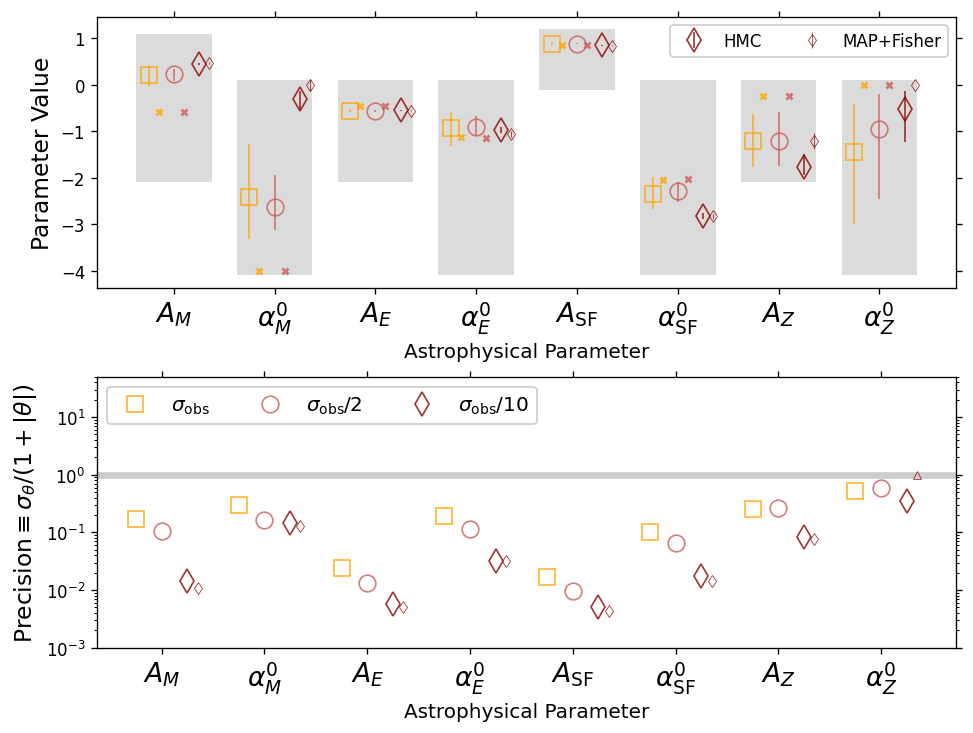

In [6]:
# Define x positions for the labels (parameters)
xvals = np.arange(len(parlabels))

### TO DO: automate the figsize for different numbers of constraints/parameters
fig, axes = plt.subplots(nrows=2,ncols=1,figsize=(8,6),constrained_layout=True,dpi=120)

ax_mean = axes[0]
ax_precision = axes[1]

# TO DO: automate this for different # of constraints/parameters (or let user adapt on their own...)
mockerr_shifts = {0: -0.25, 1: 0.0, 2: 0.25}  # SMHM, +fgas, +mzr
adam_shift = 0.1

### precision and accuracy -- loop over each constraint type

for filenum,filename in enumerate(filenames):


    adam_file = adam_files[filenum]
    adam_mus, adam_sigmas = get_adam_fisher(adam_file)
    
    # extract this run's stuff
    mockerr_color = mockerr_colors[filenum]
    mockerr_label = mockerr_labels[filenum]
    mockerr_marker = mockerr_markers[filenum]

    shift = mockerr_shifts[filenum]

    ### get this run's posterior dataframe
    samples_df = get_posterior(filename)

    ### loop over each parameter for precision and accuracy
    for pnum, pval in enumerate(params_free):

        samples_param = samples_df[pval].values

        # compute half of 84-16 percentile width as posterior width/uncertainty (comparable to sigma_Fisher, if posterior is Gaussian)
        p16, p50,p84 = np.percentile(samples_param,[16,50,84]) 
        pwidth = (p84-p16)/2.0 
        pfrac = pwidth / (1+np.abs(p50)) # fractional uncertainty normalized by median parameter value 
        
        ax_precision.plot(xvals[pnum] + shift, pfrac,mockerr_marker,color=mockerr_color,
                              alpha=0.8, mfc='none',
                              ms=10, mew=1,label=mockerr_label if pnum == 0 else '__none__')

        
        ax_mean.errorbar(xvals[pnum] + shift, p50,yerr=[[p50-p16],[p84-p50]],color=mockerr_color,
                     alpha=0.8, mfc='none',fmt=mockerr_marker,elinewidth=1,
                     ms=10, mew=1,label='HMC' if pnum == 0 and filenum==2 else '__none__')

        ### plot a thin vertical gray stripe in background denoting each parameter's large uniform prior range
        ax_mean.fill_between([xvals[pnum] - 1.5*shift, xvals[pnum] + 1.5*shift],
                             parlims[pval][0], parlims[pval][1],
                             color='gray',alpha=0.15,zorder=0,edgecolor='none')

        ### adam fisher 
        if np.isfinite(adam_sigmas[0]) == True:
            
            ax_precision.plot(xvals[pnum] + shift + adam_shift, adam_sigmas[pnum]/(1+np.abs(adam_mus[pnum])),mockerr_marker,
                              color=mockerr_color,alpha=0.8,ms=5, mfc='none',mew=0.5,label='__none__')            

            ax_mean.errorbar(xvals[pnum] + shift + adam_shift, adam_mus[pnum], yerr=adam_sigmas[pnum],color=mockerr_color,
                             alpha=0.8,fmt=mockerr_marker,ms=5,mfc='none',mew=0.5,elinewidth=0.5,
                             label= 'MAP+Fisher' if pnum == 0 else '__none__')

            ### for scaleerrtenth, sigma(alphaZ)=0.0 (maybe because it's at border), so change it to lower limit triangle at 1.0 
            if pnum == len(params_free)-1: 
                ax_precision.plot(xvals[pnum] + shift + adam_shift, 1.0,'^',
                                  color=mockerr_color,alpha=0.8,ms=5, mfc='none',mew=0.5,label='__none__')                            

        else: # plot small x since not min so no fisher errors
            # ax_precision.plot(xvals[pnum] + shift + adam_shift, adam_sigmas[pnum]/adam_mus[pnum],'x',color=mockerr_color,
            #                       alpha=0.8,ms=5, mfc='none',mew=0.5,label='__none__')            
            
            ax_mean.plot(xvals[pnum] + shift + adam_shift, adam_mus[pnum],'X',color=mockerr_color,
                             alpha=0.8,ms=5,mec='none',mew=0.5,label='__none__')            


### precision and accuracy subplot labels, limits, etc. 

# first common aesthetics for precision and accuracy

# ax_precision.errorbar(parlabels,np.full(len(parlabels),0),alpha=0)
ax_precision.set_xticks(xvals)
ax_precision.set_xticklabels(list(parlabels.values()), rotation=0,fontsize=16)
ax_precision.set_xlabel('Astrophysical Parameter',fontsize=12)

ax_precision.legend(loc='upper left',fontsize=12,fancybox=True,framealpha=1,ncol=3)#,bbox_to_anchor=(0,-0.05))
ax_precision.set_ylabel(r'Precision$\equiv \sigma_{\theta}/(1+|\theta|)$',fontsize=14)
ax_precision.set_yscale('log')
ax_precision.set_ylim(1e-3,5e1)

ax_precision.axhline(1.0,color='k',lw=4,alpha=0.2,label='__none__',zorder=0)

ax_mean.set_xticks(xvals)
ax_mean.set_xticklabels(list(parlabels.values()), rotation=0,fontsize=16)
ax_mean.set_xlabel('Astrophysical Parameter',fontsize=12)

ax_mean.set_ylabel(r'Parameter Value',fontsize=14)

ax_mean.legend(loc='upper right',fontsize=10,fancybox=True,framealpha=1,ncol=2)#,bbox_to_anchor=(0,-0.05))

# plt.savefig('/mnt/ceph/users/vpandya/sapphire_outputs/figures/precision_obs.png',bbox_inches='tight',dpi=300,facecolor='w')
